In [211]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from uncertainties.umath import sqrt
from scipy import odr

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [274]:
df0 = pd.read_csv('./models/BFreqRatiosUncertain.csv', skiprows=2,
                 usecols=[0,2,3,4,5], names=['Freq', 'Rb85', 'Rb85_err', 'Rb87', 'Rb87_err'])
df1 = pd.read_csv('./models/quadraticRb85ZeemanData.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4','dip5','udip5','dip6','udip6'])
df2 = pd.read_csv('./models/quadraticRb87ZeemanData-oldCalibration.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4']) # TODO: using old Rb87 data

bAdjustment = 1 # put it into the csv data now

freqLow = df0['Freq'].values / 1000 # kHz->MHz
freq85High = df1['Freq'].values # MHz
freq87High = df2['Freq'].values # MHz


Rb85Low = df0['Rb85'].values # B field in T
uRb85Low = df0['Rb85_err'].values # B field in T

Rb87Low = df0['Rb87'].values # B field in T
uRb87Low = df0['Rb87_err'].values # B field in T


# Take only the 25 and 195kHz values from low range
# freqLow = [freqLow[0],freqLow[-1]]
# Rb85Low = [Rb85Low[0],Rb85Low[-1]]
# uRb85Low = [uRb85Low[0],uRb85Low[-1]]
# Rb87Low = [Rb87Low[0],Rb87Low[-1]]
# uRb87Low = [uRb87Low[0],uRb87Low[-1]]

# Take only the 25kHz values from low range
# freqLow = [freqLow[0]]
# Rb85Low = [Rb85Low[0]]
# uRb85Low = [uRb85Low[0]]
# Rb87Low = [Rb87Low[0]]
# uRb87Low = [uRb87Low[0]]



Rb85HighD1 = bAdjustment * df1['dip1'].values # B field in T
Rb85HighD2 = bAdjustment * df1['dip2'].values # B field in T
Rb85HighD3 = bAdjustment * df1['dip3'].values # B field in T
Rb85HighD4 = bAdjustment * df1['dip4'].values # B field in T
Rb85HighD5 = bAdjustment * df1['dip5'].values # B field in T
Rb85HighD6 = bAdjustment * df1['dip6'].values # B field in T
uRb85HighD1 = bAdjustment * df1['udip1'].values # B field in T
uRb85HighD2 = bAdjustment * df1['udip2'].values # B field in T
uRb85HighD3 = bAdjustment * df1['udip3'].values # B field in T
uRb85HighD4 = bAdjustment * df1['udip4'].values # B field in T
uRb85HighD5 = bAdjustment * df1['udip5'].values # B field in T
uRb85HighD6 = bAdjustment * df1['udip6'].values # B field in T

Rb87HighD1 = bAdjustment * df2['dip1'].values # B field in T
Rb87HighD2 = bAdjustment * df2['dip2'].values # B field in T
Rb87HighD3 = bAdjustment * df2['dip3'].values # B field in T
Rb87HighD4 = bAdjustment * df2['dip4'].values # B field in T
uRb87HighD1 = bAdjustment * df2['udip1'].values # B field in T
uRb87HighD2 = bAdjustment * df2['udip2'].values # B field in T
uRb87HighD3 = bAdjustment * df2['udip3'].values # B field in T
uRb87HighD4 = bAdjustment * df2['udip4'].values # B field in T


freq85 = np.concatenate((freqLow, freq85High))

Rb85d1 = np.concatenate((Rb85Low,Rb85HighD1))
Rb85d2 = np.concatenate((Rb85Low,Rb85HighD2))
Rb85d3 = np.concatenate((Rb85Low,Rb85HighD3))
Rb85d4 = np.concatenate((Rb85Low,Rb85HighD4))
Rb85d5 = np.concatenate((Rb85Low,Rb85HighD5))
Rb85d6 = np.concatenate((Rb85Low,Rb85HighD6))

uRb85d1 = np.concatenate((uRb85Low,uRb85HighD1))
uRb85d2 = np.concatenate((uRb85Low,uRb85HighD2))
uRb85d3 = np.concatenate((uRb85Low,uRb85HighD3))
uRb85d4 = np.concatenate((uRb85Low,uRb85HighD4))
uRb85d5 = np.concatenate((uRb85Low,uRb85HighD5))
uRb85d6 = np.concatenate((uRb85Low,uRb85HighD6))


freq87 = np.concatenate((freqLow, freq87High))

Rb87d1 = np.concatenate((Rb87Low,Rb87HighD1))
Rb87d2 = np.concatenate((Rb87Low,Rb87HighD2))
Rb87d3 = np.concatenate((Rb87Low,Rb87HighD3))
Rb87d4 = np.concatenate((Rb87Low,Rb87HighD4))

uRb87d1 = np.concatenate((uRb87Low,uRb87HighD1))
uRb87d2 = np.concatenate((uRb87Low,uRb87HighD2))
uRb87d3 = np.concatenate((uRb87Low,uRb87HighD3))
uRb87d4 = np.concatenate((uRb87Low,uRb87HighD4))

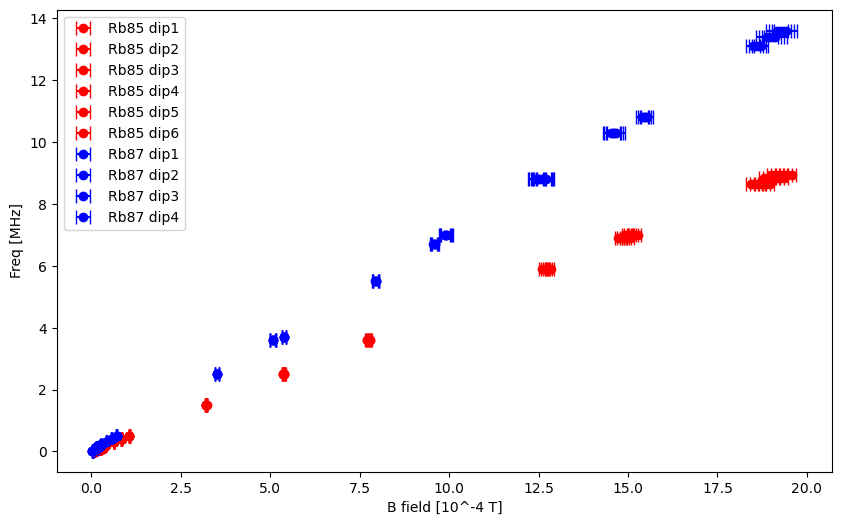

In [275]:
plt.figure(figsize=(10, 6))
plt.errorbar(Rb85d1 * 10**4, freq85, xerr=uRb85d1 * 10**4, capsize=5, label='Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, freq85, xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='Rb85 dip6', fmt='o', color='red')


plt.errorbar(Rb87d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
plt.errorbar(Rb87d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
plt.errorbar(Rb87d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
plt.errorbar(Rb87d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor quadratic range Mar13", dpi=300)

plt.show()

In [276]:
h = 6.626 * 10**(-34)
hbar = h / (2*np.pi)
gF87 = 0.4988 # (from gemini, aligns with other sources)
gF85 = 0.3337 # (from gemini, aligns with other sources)
muB = 9.2740 * 10**(-24) # J/T (from NIST standard units)
# muN = 5.05078 * 10**(-27) # J/T (from NIST standard units)
gJ = 2.0023193043622 # electron G factor (from Steck)
# gI = 6.6743 * 10**(-11) #m^3 /kgs^2
g_J = gJ
# g_I = gI
mu_B = muB
gI85 = -0.00029364 # (from steck)
gI87 = -0.0009951414 # (from steck)

def muI(I, gI):
    return gI * muB * I

dEhfs87 =  4.528 * 10**(-24) #J (from gemini)
dEhfs85 =  2.011 * 10**(-24) #J (from gemini)
# nuhf87 =  4.2939 *10**(10) #rad/s (from gemini)
# nuhf85 =  1.9074 *10**(10) #rad/s (from gemini)

#M_F is the integer for the associated dip number

# def MHzToE(freqArr):
#     return freqArr / 10**6 * h
#
# def kHzToE(freqArr):
#     return freqArr / 10**3 * h

def quadratic_func(p,x):
    return p[0]*x**2 + p[1]*x + p[2]

def quadratic_0intercept(p, x):
    return p[0] * x**2 + p[1] * x

def quadratic_only_87(p, x):
    I = 3/2

    bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I, gI))/((2*I + 1) * h))
    # bExpected = (0.4988 * muB) /h * x
    return p[0] * x**2 + bExpected * x
def quadratic_only_85(p, x):
    I = 5/2
    bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I, gI))/((2*I + 1) * h))
    # bExpected = (0.3337 * muB) /h * x
    return p[0] * x**2 + bExpected * x

def fitQuadraticZeeman_87(B, uB, freq, MfUpper):
    quad_model = odr.Model(quadratic_0intercept)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)

    # aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)
    # bExpected = (0.4988 * muB) /h

    I = 3/2
    dEhfs = dEhfs87
    gI = gI87
    M = MfUpper
    aExpected = - 2*(((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I, gI))/((2*I + 1) * h))


    p0 = [aExpected, bExpected]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit, b_fit = output.beta
    a_err, b_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    b = ufloat(b_fit,b_err)

    print(f"a fit: {a:.2ue}, expected {aExpected:.6e}")
    print(f"b fit: {b:.2ue}, expected {bExpected:.6e}")
    return a,b, aExpected, bExpected, output

def fitQuadraticZeeman_85(B, uB, freq, MfUpper):
    quad_model = odr.Model(quadratic_0intercept)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)

    # linear term is from L=0, not L=1, so assume it's also L=0 for quadratic, so use the following equation:
    # f = -B * ((g_J mu_B + 2(1+1/I)mu_I)/((2I + 1) * h)) + 2B^2* (((M-0.5)(g_J mu_B + mu_I/I)^2)/((2I + 1)^2 h * dEhfs))


    I = 5/2
    gI = gI85
    dEhfs = dEhfs85
    M = MfUpper

    # aExpected = 2*(((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    # bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I, gI))/((2*I + 1) * h))


    # have to use larger F term, so use the following equation
    # f = B * ((g_J mu_B - 2mu_I)/((2I + 1) * h)) + 2B^2* (((M-0.5)(g_J mu_B + mu_I/I)^2)/((2I + 1)^2 h * dEhfs))
    aExpected = - 2 * (((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    bExpected = ((g_J * mu_B - 2*muI(I, gI))/((2*I + 1) * h))


    # aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)
    # bExpected = (0.3337 * muB) /h

    p0 = [aExpected, bExpected]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit, b_fit = output.beta
    a_err, b_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    b = ufloat(b_fit,b_err)

    print(f"a fit: {a:.2ue}, expected {aExpected:.6e}")
    print(f"b fit: {b:.2ue}, expected {bExpected:.6e}")
    return a,b, aExpected, bExpected, output

def fitFullQuadraticZeeman_85(B, uB, freq, MfUpper):
    quad_model = odr.Model(quadratic_func)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)

    # linear term is from L=0, not L=1, so assume it's also L=0 for quadratic, so use the following equation:
    # f = -B * ((g_J mu_B + 2(1+1/I)mu_I)/((2I + 1) * h)) + 2B^2* (((M-0.5)(g_J mu_B + mu_I/I)^2)/((2I + 1)^2 h * dEhfs))


    I = 5/2
    dEhfs = dEhfs85
    gI = gI85
    M = MfUpper

    # aExpected = 2*(((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    # bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I))/((2*I + 1) * h))


    # have to use larger F term, so use the following equation
    # f = B * ((g_J mu_B - 2mu_I)/((2I + 1) * h)) + 2B^2* (((M-0.5)(g_J mu_B + mu_I/I)^2)/((2I + 1)^2 h * dEhfs))
    aExpected = - 2 * (((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    bExpected = ((g_J * mu_B - 2*muI(I, gI))/((2*I + 1) * h))


    # aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)
    # bExpected = (0.3337 * muB) /h

    p0 = [aExpected, bExpected,0]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit, b_fit, c_fit = output.beta
    a_err, b_err, c_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    b = ufloat(b_fit,b_err)
    c = ufloat(c_fit,c_err)

    print(f"a fit: {a:.2ue}, expected {aExpected:.6e}")
    print(f"b fit: {b:.2ue}, expected {bExpected:.6e}")
    print(f"c fit: {c:.2ue}, expected 0")
    return a,b,c, aExpected, bExpected, output

def fitQuadraticOnlyZeeman_87(B, uB, freq, MfUpper):
    quad_model = odr.Model(quadratic_only_87)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)


    I = 3/2
    dEhfs = dEhfs87
    gI = gI87
    M = MfUpper
    aExpected = -2*(((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
    # bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I))/((2*I + 1) * h))

    # aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)

    p0 = [aExpected]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit = output.beta
    a_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    # b = ufloat(b_fit,b_err)

    print(f"a fit: {a:.2ue}, expected {aExpected:.6e}")
    # print(f"b fit: {b:.2ue}, expected {bExpected:.6e}")
    return a, aExpected, output

def fitQuadraticOnlyZeeman_85(B, uB, freq, MfUpper):
    quad_model = odr.Model(quadratic_only_85)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)

    # aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)

    I = 3/2
    dEhfs = dEhfs87
    gI = gI87
    M = MfUpper
    aExpected = -2*(((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))

    p0 = [aExpected]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit = output.beta
    a_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    # b = ufloat(b_fit,b_err)

    print(f"a fit: {a:.2ue}, expected {aExpected:.6e}")
    # print(f"b fit: {b:.2ue}, expected {bExpected:.6e}")
    return a, aExpected, output

#f ~= (g_F mu_B/h) B + (g_J - g_I)^2 mu_B^2/(h^2 deltaE_hfs) (1 - 2M_F) B^2
# calling quadratic func we get a=(g_J - g_I)^2 mu_B^2/(h*2 deltaE_hfs) (1 - 2M_F), b=(g_F mu_B/h), c=0

# use scipy.odr to fit with the B field uncertainty (only have xerr, no yerr)

def linear_wInt(m, x):
    return m[0] * x + m[1]

def fitLinearZeeman(B, uB, freq):
    linear_model = odr.Model(linear_wInt)
    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz
    p0 = [10**9,0.1]
    my_odr = odr.ODR(my_data, linear_model, beta0=p0)
    output = my_odr.run()
    m_fit, b_fit = output.beta
    m_err, b_err = output.sd_beta
    m = ufloat(m_fit,m_err)
    b = ufloat(b_fit,b_err)
    print(f"m fit: {m:.2ue}")
    print(f"b fit: {b:.2ue}")
    return m,b

def BtoFreqUncertainty(B, uB, a, b):
    lower = a * (B-uB)**2 + b * (B-uB)
    upper = a * (B+uB)**2 + b * (B+uB)
    # freq = a * (B)**2 + b * (B)
    # return freq, (lower+upper)/2
    return abs(upper-lower)/2 / 10**6 # Hz to MHz


In [277]:
# m85d1, b85d1 = fitLinearZeeman(Rb85HighD1, uRb85HighD1,freq85High)

# # Below values use the high B range only
# print("Rubidium 85:")
# a85d1,b85d1, a85d1Expected, b85d1Expected, output85d1 = fitQuadraticZeeman_85(Rb85HighD1, uRb85HighD1,freq85High, -2)
# a85d2,b85d2, a85d2Expected, b85d2Expected, output85d2 = fitQuadraticZeeman_85(Rb85HighD2, uRb85HighD2, freq85High, -1)
# a85d3,b85d3, a85d3Expected, b85d3Expected, output85d3 = fitQuadraticZeeman_85(Rb85HighD3, uRb85HighD3, freq85High, 0)
# a85d5,b85d5, a85d5Expected, b85d5Expected, output85d4 = fitQuadraticZeeman_85(Rb85HighD4, uRb85HighD4, freq85High, 1)
# a85d5,b85d5, a85d5Expected, b85d5Expected, output85d5 = fitQuadraticZeeman_85(Rb85HighD5, uRb85HighD5, freq85High, 2)
# a85d6,b85d6, a85d6Expected, b85d6Expected, output85d6 = fitQuadraticZeeman_85(Rb85HighD6, uRb85HighD6, freq85High, 3)
#
# print("\nRubidium 87:")
# a87d1,b87d1, a87d1Expected, b87d1Expected, output87d1 = fitQuadraticZeeman_87(Rb87HighD1, uRb87HighD1, freq87High, -1)
# a87d2,b87d2, a87d2Expected, b87d2Expected, output87d2 = fitQuadraticZeeman_87(Rb87HighD2, uRb87HighD2, freq87High, 0)
# a87d3,b87d3, a87d3Expected, b87d3Expected, output87d3 = fitQuadraticZeeman_87(Rb87HighD3, uRb87HighD3, freq87High, 1)
# a87d4,b87d4, a87d4Expected, b87d4Expected, output87d4 = fitQuadraticZeeman_87(Rb87HighD4, uRb87HighD4, freq87High, 2)

# Below values use the full range
print("Rubidium 85:")
a85d1,b85d1, a85d1Expected, b85d1Expected, output85d1 = fitQuadraticZeeman_85(Rb85d1, uRb85d1, freq85, -2)
a85d2,b85d2, a85d2Expected, b85d2Expected, output85d2 = fitQuadraticZeeman_85(Rb85d2, uRb85d2, freq85, -1)
a85d3,b85d3, a85d3Expected, b85d3Expected, output85d3 = fitQuadraticZeeman_85(Rb85d3, uRb85d3, freq85, 0)
a85d4,b85d4, a85d5Expected, b85d4Expected, output85d4 = fitQuadraticZeeman_85(Rb85d4, uRb85d4, freq85, 1)
a85d5,b85d5, a85d5Expected, b85d5Expected, output85d5 = fitQuadraticZeeman_85(Rb85d5, uRb85d5, freq85, 2)
a85d6,b85d6, a85d6Expected, b85d6Expected, output85d6 = fitQuadraticZeeman_85(Rb85d6, uRb85d6, freq85, 3)

print("\nRubidium 87:")
a87d1,b87d1, a87d1Expected, b87d1Expected, output87d1 = fitQuadraticZeeman_87(Rb87d1, uRb87d1, freq87, -1)
a87d2,b87d2, a87d2Expected, b87d2Expected, output87d2 = fitQuadraticZeeman_87(Rb87d2, uRb87d2, freq87, 0)
a87d3,b87d3, a87d3Expected, b87d3Expected, output87d3 = fitQuadraticZeeman_87(Rb87d3, uRb87d3, freq87, 1)
a87d4,b87d4, a87d4Expected, b87d4Expected, output87d4 = fitQuadraticZeeman_87(Rb87d4, uRb87d4, freq87, 2)


uFreq85d1 = BtoFreqUncertainty(Rb85d1, uRb85d1, a85d1.n, b85d1.n)
uFreq85d2 = BtoFreqUncertainty(Rb85d2, uRb85d2, a85d2.n, b85d2.n)
uFreq85d3 = BtoFreqUncertainty(Rb85d3, uRb85d3, a85d3.n, b85d3.n)
uFreq85d4 = BtoFreqUncertainty(Rb85d4, uRb85d4, a85d4.n, b85d4.n)
uFreq85d5 = BtoFreqUncertainty(Rb85d5, uRb85d5, a85d5.n, b85d5.n)
uFreq85d6 = BtoFreqUncertainty(Rb85d6, uRb85d6, a85d6.n, b85d6.n)

uFreq87d1 = BtoFreqUncertainty(Rb87d1, uRb87d1, a87d1.n, b87d1.n)
uFreq87d2 = BtoFreqUncertainty(Rb87d2, uRb87d2, a87d2.n, b87d2.n)
uFreq87d3 = BtoFreqUncertainty(Rb87d3, uRb87d3, a87d3.n, b87d3.n)
uFreq87d4 = BtoFreqUncertainty(Rb87d4, uRb87d4, a87d4.n, b87d4.n)


Rb85d1Residual = freq85 - quadratic_0intercept([a85d1.n,b85d1.n], Rb85d1) / 10**6
Rb85d2Residual = freq85 - quadratic_0intercept([a85d2.n,b85d2.n], Rb85d2) / 10**6
Rb85d3Residual = freq85 - quadratic_0intercept([a85d3.n,b85d3.n], Rb85d3) / 10**6
Rb85d4Residual = freq85 - quadratic_0intercept([a85d4.n,b85d4.n], Rb85d4) / 10**6
Rb85d5Residual = freq85 - quadratic_0intercept([a85d5.n,b85d5.n], Rb85d5) / 10**6
Rb85d6Residual = freq85 - quadratic_0intercept([a85d6.n,b85d6.n], Rb85d6) / 10**6

Rb87d1Residual = freq87 - quadratic_0intercept([a87d1.n,b87d1.n], Rb87d1) / 10**6
Rb87d2Residual = freq87 - quadratic_0intercept([a87d2.n,b87d2.n], Rb87d2) / 10**6
Rb87d3Residual = freq87 - quadratic_0intercept([a87d3.n,b87d3.n], Rb87d3) / 10**6
Rb87d4Residual = freq87 - quadratic_0intercept([a87d4.n,b87d4.n], Rb87d4) / 10**6


bFullAxis = np.linspace(0,20/10**4)

# TODO: metric for quality of fit like chisqr


# print(uFreq85d1)

Rubidium 85:
a fit: (1.34+/-0.23)e+10, expected 3.593168e+10
b fit: (4.6695+/-0.0028)e+09, expected 4.674295e+09
a fit: (-1.6+/-2.3)e+09, expected 2.155901e+10
b fit: (4.6703+/-0.0029)e+09, expected 4.674295e+09
a fit: (-1.62+/-0.23)e+10, expected 7.186335e+09
b fit: (4.6708+/-0.0029)e+09, expected 4.674295e+09
a fit: (-3.03+/-0.23)e+10, expected -7.186335e+09
b fit: (4.6708+/-0.0030)e+09, expected 4.674295e+09
a fit: (-4.42+/-0.24)e+10, expected -2.155901e+10
b fit: (4.6711+/-0.0031)e+09, expected 4.674295e+09
a fit: (-5.82+/-0.24)e+10, expected -3.593168e+10
b fit: (4.6716+/-0.0031)e+09, expected 4.674295e+09

Rubidium 87:
a fit: (3.3+/-2.0)e+10, expected 2.152844e+10
b fit: (6.995+/-0.020)e+09, expected 6.988894e+09
a fit: (1.8+/-2.0)e+10, expected 7.176145e+09
b fit: (6.995+/-0.020)e+09, expected 6.988894e+09
a fit: (0.3+/-1.9)e+10, expected -7.176145e+09
b fit: (6.996+/-0.020)e+09, expected 6.988894e+09
a fit: (-1.2+/-1.9)e+10, expected -2.152844e+10
b fit: (6.996+/-0.020)e+09, ex

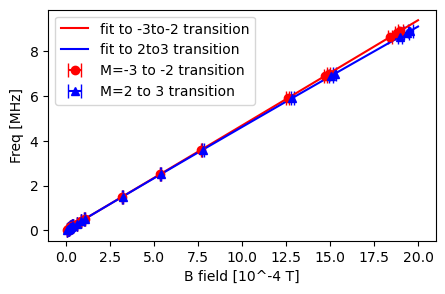

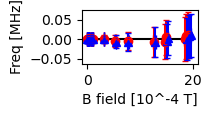

In [278]:
plt.figure(figsize=(5,3))
plt.errorbar(Rb85d1 * 10**4, freq85, xerr=uRb85d1 * 10**4, capsize=5, label='M=-3 to -2 transition', fmt='o', color='red')
# plt.errorbar(Rb85d2 * 10**4, freq85, xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
# plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
# plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
# plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='M=2 to 3 transition', fmt='^', color='blue')

# plt.errorbar(Rb87d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
# # plt.errorbar(Rb87d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
# # plt.errorbar(Rb87d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
# plt.errorbar(Rb87d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d1.beta, bFullAxis) / 10**6, label='fit to -3to-2 transition', color='red')
# # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d2.beta, bFullAxis) / 10**6, label='fit to Rb85 dip2', color='red')
# # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d3.beta, bFullAxis) / 10**6, label='fit to Rb85 dip3', color='red')
# # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d4.beta, bFullAxis) / 10**6, label='fit to Rb85 dip4', color='red')
# # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d5.beta, bFullAxis) / 10**6, label='fit to Rb85 dip5', color='red')
plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d6.beta, bFullAxis) / 10**6, label='fit to 2to3 transition', color='blue')

# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d1.beta, bFullAxis) / 10**6, label='fit to Rb87 dip1', color='blue')
# # # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d2.beta, bFullAxis) / 10**6, label='fit to Rb87 dip2', color='blue')
# # # plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d3.beta, bFullAxis) / 10**6, label='fit to Rb87 dip3', color='blue')
# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d4.beta, bFullAxis) / 10**6, label='fit to Rb87 dip4', color='blue')


# bFullAxis = np.linspace(0,2500/10**4)


# plt.plot(bFullAxis * 10 ** 4, linear_wInt([4.67e9,0], bFullAxis) / 10 ** 6, label='Linear ', color='black')


# print("\nRb87:")
# I = 3/2
# dEhfs = dEhfs87
# for M in [-1,2]:
#     # M = 1.5
#     aExpected = 2*(((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
#     bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I))/((2*I + 1) * h))
#     print(f"a expected {aExpected:.6e}")
#     print(f"b expected {bExpected:.6e}")
#     plt.plot(bFullAxis * 10**4, quadratic_0intercept([aExpected, bExpected], bFullAxis) / 10**6, label='expected Rb87', color='purple')
#
#     # aExpected = - 2 * (((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
#     # bExpected = ((g_J * mu_B - 2*muI(I))/((2*I + 1) * h))
#     # print(f"a expected {aExpected:.6e}")
#     # print(f"b expected {bExpected:.6e}")
#     # plt.plot(bFullAxis * 10**4, quadratic_0intercept([aExpected, bExpected], bFullAxis) / 10**6, label='expected Rb87', color='blue')
#
#
# print("\nRb85:")
# I = 5/2
# dEhfs = dEhfs85
# for M in [-2,3]:
#     # M = 1.5
#     # aExpected = 2*(((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
#     # bExpected = ((g_J * mu_B + 2*(1+1/I)*muI(I))/((2*I + 1) * h))
#     aExpected = 2 * (((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
#     bExpected = ((g_J * mu_B - 2*muI(I))/((2*I + 1) * h))
#
#     # print(f"a expected {aExpected:.6e}")
#     # print(f"b expected {bExpected:.6e}")
#     plt.plot(bFullAxis * 10**4, quadratic_0intercept([aExpected, bExpected], bFullAxis) / 10**6, label='expected Rb85', color='orange')
#
# print("\nRb85 simpler model:")
# for MfUpper in [-2,-1,0,1,2,3]:
#     aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2 * MfUpper)
#     bExpected = (0.3337 * muB) /h
#
#     print(f"a expected {aExpected:.6e}")
#     plt.plot(bFullAxis * 10**4, quadratic_0intercept([aExpected, bExpected], bFullAxis) / 10**6, label='simpler expected Rb85', color='orange')


# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
plt.legend()
# plt.xlim(0,1)
# plt.ylim(0,1)
plt.savefig("./figures/quadratic Zeeman mar 27.pdf", dpi=300, bbox_inches='tight')
plt.show()

# M = -2
# I = 5/2
# dEhfs = dEhfs85
# aExpected = 2 * (((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
# bExpected = ((g_J * mu_B - 2*muI(I))/((2*I + 1) * h))
# residual = freq85 - quadratic_0intercept([aExpected, bExpected], Rb85d1) / 10**6
# plt.errorbar(Rb85d1 * 10**4, residual, xerr=uRb85d1 * 10**4, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
#
# M = -1
# I = 3/2
# dEhfs = dEhfs87
# aExpected = 2 * (((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
# bExpected = ((g_J * mu_B - 2*muI(I))/((2*I + 1) * h))
# residual = freq87 - quadratic_0intercept([aExpected, bExpected], Rb87d1) / 10**6
# plt.errorbar(Rb87d1 * 10**4, residual, xerr=uRb87d1 * 10**4, capsize=5, label='residual of Rb87 dip1', fmt='o', color='blue')
#
# plt.ylabel('Freq [MHz]')
# plt.xlabel('B field [10^-4 T]')
# plt.savefig("./figures/quadratic Zeeman residual Ideal mar 27", dpi=300)
# plt.show()

plt.figure(figsize=(1.5,0.7))
plt.plot(bFullAxis * 10**4, np.zeros(len(bFullAxis)), color="black")
plt.errorbar(Rb85d1 * 10**4, Rb85d1Residual, xerr=uRb85d1 * 10**4, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
# plt.errorbar(Rb85d2 * 10**4, Rb85d2Residual, xerr=uRb85d2 * 10**4, capsize=5, label='residual of Rb85 dip2', fmt='o', color='red')
# plt.errorbar(Rb85d3 * 10**4, Rb85d3Residual, xerr=uRb85d3 * 10**4, capsize=5, label='residual of Rb85 dip3', fmt='o', color='red')
# plt.errorbar(Rb85d4 * 10**4, Rb85d4Residual, xerr=uRb85d4 * 10**4, capsize=5, label='residual of Rb85 dip4', fmt='o', color='red')
# plt.errorbar(Rb85d5 * 10**4, Rb85d5Residual, xerr=uRb85d5 * 10**4, capsize=5, label='residual of Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, Rb85d6Residual, xerr=uRb85d6 * 10**4, capsize=5, label='residual of Rb85 dip6', fmt='^', color='blue')

plt.errorbar(Rb85d1 * 10**4, Rb85d1Residual, yerr=uFreq85d1, capsize=2, markersize=3, label='residual of Rb85 dip1', fmt='o', color='red')
# plt.errorbar(Rb85d2 * 10**4, Rb85d2Residual, yerr=uFreq85d2, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
# plt.errorbar(Rb85d3 * 10**4, Rb85d3Residual, yerr=uFreq85d3, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
# plt.errorbar(Rb85d4 * 10**4, Rb85d4Residual, yerr=uFreq85d4, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
# plt.errorbar(Rb85d5 * 10**4, Rb85d5Residual, yerr=uFreq85d5, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, Rb85d6Residual, yerr=uFreq85d6, capsize=2, markersize=3, label='residual of Rb85 dip1', fmt='^', color='blue')

# plt.errorbar(Rb87d1 * 10**4, Rb87d1Residual, xerr=uRb87d1 * 10**4, capsize=5, label='residual of Rb87 dip1', fmt='o', color='blue')
# plt.errorbar(Rb87d2 * 10**4, Rb87d2Residual, xerr=uRb87d2 * 10**4, capsize=5, label='residual of Rb87 dip1', fmt='o', color='blue')
# plt.errorbar(Rb87d3 * 10**4, Rb87d3Residual, xerr=uRb87d3 * 10**4, capsize=5, label='residual of Rb87 dip1', fmt='o', color='blue')
# plt.errorbar(Rb87d4 * 10**4, Rb87d4Residual, xerr=uRb87d4 * 10**4, capsize=5, label='residual of Rb87 dip1', fmt='o', color='blue')

# print("max residual:", max(Rb85d1Residual))
# print("max residual:", max(Rb85d2Residual))
# print("max residual:", max(Rb85d3Residual))
# print("max residual:", max(Rb85d4Residual))
# print("max residual:", max(Rb85d5Residual))
# print("max residual:", max(Rb85d6Residual))
#
# print("min residual:", min(Rb85d1Residual))
# print("min residual:", min(Rb85d2Residual))
# print("min residual:", min(Rb85d3Residual))
# print("min residual:", min(Rb85d4Residual))
# print("min residual:", min(Rb85d5Residual))
# print("min residual:", min(Rb85d6Residual))

plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
plt.savefig("./figures/quadratic Zeeman residual mar 27.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [281]:

# aFitted = -2*(((M-0.5)*(g_J * mu_B + muI(I, gI)/I)**2)/((2*I + 1)**2 * h * dEhfs))
# dip1 has M=-2
# gJImuB = (g_J + g_I)*muB
I = 5/2
gI = gI85
# (gJ+gI) * muB
gJImuB_Rb85 = []

for M,a in zip([-2,-1,0,1,2,3],[a85d1,a85d2,a85d3,a85d4,a85d5,a85d6]):
    # a = a + 2.3e10
    if (((a*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))) < 0):
        continue
    # print(sqrt((a85d1*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))))
    gJImuB_Rb85.append(sqrt((a*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))))

# for gJImuB in gJImuB_Rb85:
#     print(gJImuB)

avggJImuB_Rb85 = np.mean(gJImuB_Rb85)

print("Expected: " + str((gJ+gI) * muB))
print(avggJImuB_Rb85)

# ((g_J * mu_B - 2*muI(I, gI))/((2*I + 1) * h))

# (gJ-2*I*gI) * muB
gJ2ImuB_Rb85 = []

for M,b in zip([-2,-1,0,1,2,3],[b85d1,b85d2,b85d3,b85d4,b85d5,b85d6]):
    # print(b85d1*((2*I + 1) * h))
    gJ2ImuB_Rb85.append(b*((2*I + 1) * h))

avggJ2ImuB_Rb85 = np.mean(gJ2ImuB_Rb85)

print("Expected: " + str((gJ-2*I*gI) * muB))
print(avggJ2ImuB_Rb85)


print("Expected: " + str((gJ+gI)/(gJ-2*I*gI)))
print(avggJImuB_Rb85/avggJ2ImuB_Rb85)

Expected: 1.856678601129504e-23
(3.74+/-0.07)e-23
Expected: 1.8583125315455042e-23
(1.8569+/-0.0005)e-23
Expected: 0.9991207450909017
2.01+/-0.04


In [282]:
I = 3/2
gI = gI87
# (gJ+gI) * muB
gJImuB_Rb87 = []

for M,a in zip([-1,0,1,2],[a87d1,a87d2,a87d3,a87d4]):
    # a = a + 2.3e10
    if (((a*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))) < 0):
        continue
    # print(sqrt((a85d1*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))))
    gJImuB_Rb87.append(sqrt((a*((2*I + 1)**2 * h * dEhfs))/(-2*(M-0.5))))

# for gJImuB in gJImuB_Rb87:
#     print(gJImuB)

avggJImuB_Rb87 = np.mean(gJImuB_Rb87)

print("Expected: " + str((gJ+gI) * muB))
print(avggJImuB_Rb87)

gJ2ImuB_Rb87 = []

for M,b in zip([-1,0,1,2],[b87d1,b87d2,b87d3,b87d4]):
    gJ2ImuB_Rb87.append(b*((2*I + 1) * h))

avggJ2ImuB_Rb87 = np.mean(gJ2ImuB_Rb87)

print("Expected: " + str((gJ-2*I*gI) * muB))
print(avggJ2ImuB_Rb87)


print("Expected: " + str((gJ+gI)/(gJ-2*I*gI)))
print(avggJImuB_Rb87/avggJ2ImuB_Rb87)

Expected: 1.856028028731144e-23
(2.2+/-0.7)e-23
Expected: 1.859719605268584e-23
(1.8541+/-0.0027)e-23
Expected: 0.9980149821903359
1.2+/-0.4


In [283]:
print("Rubidium 85:")
a85d1, a85d1Expected, output85d1 = fitQuadraticOnlyZeeman_85(Rb85HighD1, uRb85HighD1,freq85High, -2)
a85d2, a85d2Expected, output85d2 = fitQuadraticOnlyZeeman_85(Rb85HighD2, uRb85HighD2, freq85High, -1)
a85d3, a85d3Expected, output85d3 = fitQuadraticOnlyZeeman_85(Rb85HighD3, uRb85HighD3, freq85High, 0)
a85d5, a85d5Expected, output85d4 = fitQuadraticOnlyZeeman_85(Rb85HighD4, uRb85HighD4, freq85High, 1)
a85d5, a85d5Expected, output85d5 = fitQuadraticOnlyZeeman_85(Rb85HighD5, uRb85HighD5, freq85High, 2)
a85d6, a85d6Expected, output85d6 = fitQuadraticOnlyZeeman_85(Rb85HighD6, uRb85HighD6, freq85High, 3)

print("\nRubidium 87:")
a87d1, a87d1Expected, output87d1 = fitQuadraticOnlyZeeman_87(Rb87HighD1, uRb87HighD1, freq87High, -1)
a87d2, a87d2Expected, output87d2 = fitQuadraticOnlyZeeman_87(Rb87HighD2, uRb87HighD2, freq87High, 0)
a87d3, a87d3Expected, output87d3 = fitQuadraticOnlyZeeman_87(Rb87HighD3, uRb87HighD3, freq87High, 1)
a87d4, a87d4Expected, output87d4 = fitQuadraticOnlyZeeman_87(Rb87HighD4, uRb87HighD4, freq87High, 2)



bFullAxis = np.linspace(0,20/10**4)

Rubidium 85:
a fit: (2.32+/-0.14)e+10, expected 3.588073e+10
a fit: (8.6+/-1.5)e+09, expected 2.152844e+10
a fit: (-5.7+/-1.5)e+09, expected 7.176145e+09
a fit: (-1.99+/-0.13)e+10, expected -7.176145e+09
a fit: (-3.38+/-0.12)e+10, expected -2.152844e+10
a fit: (-4.75+/-0.12)e+10, expected -3.588073e+10

Rubidium 87:
a fit: (3.7+/-1.7)e+10, expected 2.152844e+10
a fit: (2.2+/-1.6)e+10, expected 7.176145e+09
a fit: (0.8+/-1.6)e+10, expected -7.176145e+09
a fit: (-0.7+/-1.6)e+10, expected -2.152844e+10


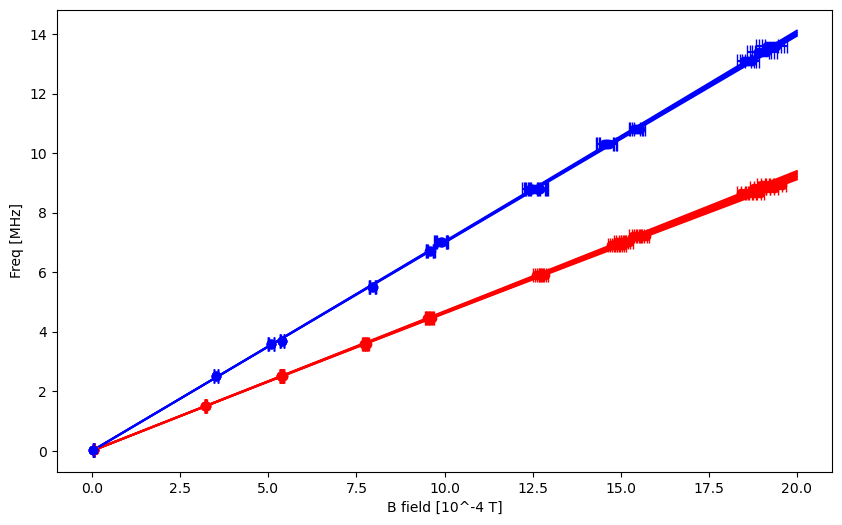

In [36]:
plt.figure(figsize=(10, 6))
plt.errorbar(Rb85d1 * 10**4, freq85, xerr=uRb85d1 * 10**4, capsize=5, label='Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, freq85, xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='Rb85 dip6', fmt='o', color='red')

plt.errorbar(Rb87d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
plt.errorbar(Rb87d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
plt.errorbar(Rb87d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
plt.errorbar(Rb87d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d1.beta, bFullAxis) / 10**6, label='fit to Rb85 dip1', color='red')
plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d2.beta, bFullAxis) / 10**6, label='fit to Rb85 dip2', color='red')
plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d3.beta, bFullAxis) / 10**6, label='fit to Rb85 dip3', color='red')
plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d4.beta, bFullAxis) / 10**6, label='fit to Rb85 dip4', color='red')
plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d5.beta, bFullAxis) / 10**6, label='fit to Rb85 dip5', color='red')
plt.plot(bFullAxis * 10**4, quadratic_only_85(output85d6.beta, bFullAxis) / 10**6, label='fit to Rb85 dip6', color='red')

plt.plot(bFullAxis * 10**4, quadratic_only_87(output87d1.beta, bFullAxis) / 10**6, label='fit to Rb87 dip1', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_only_87(output87d2.beta, bFullAxis) / 10**6, label='fit to Rb87 dip2', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_only_87(output87d3.beta, bFullAxis) / 10**6, label='fit to Rb87 dip3', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_only_87(output87d4.beta, bFullAxis) / 10**6, label='fit to Rb87 dip4', color='blue')

# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
# plt.legend()
plt.savefig("./figures/gfactor quadratic only range Mar18", dpi=300)

plt.show()

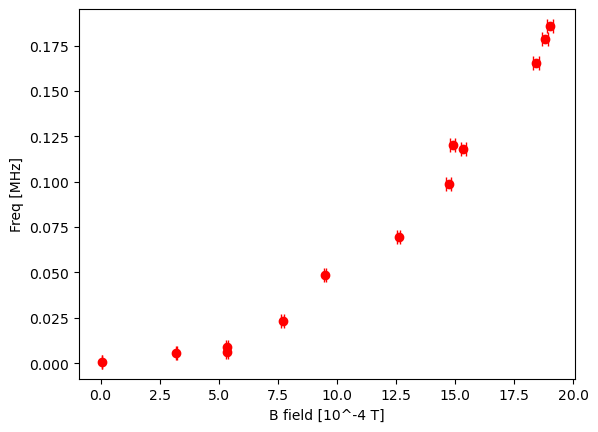

In [37]:

M = -2
I = 5/2
dEhfs = dEhfs85
aExpected = 2 * (((M-0.5)*(g_J * mu_B + muI(I)/I)**2)/((2*I + 1)**2 * h * dEhfs))
bExpected = ((g_J * mu_B - 2*muI(I))/((2*I + 1) * h))
residual = freq85 - quadratic_0intercept([aExpected, bExpected], Rb85d1) / 10**6
plt.errorbar(Rb85d1 * 10**4, residual, xerr=uRb85d1 * 10**4, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')

plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.savefig("./figures/gfactor quadratic range Mar18", dpi=300)
plt.show()

In [165]:
print("Rubidium 85:")
a85d1, b85d1, c85d1, a85d1Expected, b85d1Expected, output85d1 = fitFullQuadraticZeeman_85(Rb85d1, uRb85d1, freq85, -2)
a85d2, b85d2, c85d2, a85d2Expected, b85d2Expected, output85d2 = fitFullQuadraticZeeman_85(Rb85d2, uRb85d2, freq85, -1)
a85d3, b85d3, c85d3, a85d3Expected, b85d3Expected, output85d3 = fitFullQuadraticZeeman_85(Rb85d3, uRb85d3, freq85,  0)
a85d4, b85d4, c85d4, a85d4Expected, b85d4Expected, output85d4 = fitFullQuadraticZeeman_85(Rb85d4, uRb85d4, freq85,  1)
a85d5, b85d5, c85d5, a85d5Expected, b85d5Expected, output85d5 = fitFullQuadraticZeeman_85(Rb85d5, uRb85d5, freq85,  2)
a85d6, b85d6, c85d6, a85d6Expected, b85d6Expected, output85d6 = fitFullQuadraticZeeman_85(Rb85d6, uRb85d6, freq85,  3)

print("\nRubidium 87:")
# a87d1, a87d1Expected, output87d1 = fitQuadraticOnlyZeeman_87(Rb87HighD1, uRb87HighD1, freq87High, -1)
# a87d2, a87d2Expected, output87d2 = fitQuadraticOnlyZeeman_87(Rb87HighD2, uRb87HighD2, freq87High, 0)
# a87d3, a87d3Expected, output87d3 = fitQuadraticOnlyZeeman_87(Rb87HighD3, uRb87HighD3, freq87High, 1)
# a87d4, a87d4Expected, output87d4 = fitQuadraticOnlyZeeman_87(Rb87HighD4, uRb87HighD4, freq87High, 2)



Rb85d1Residual = freq85 - quadratic_func([a85d1.n,b85d1.n,c85d1.n], Rb85d1) / 10**6
Rb85d2Residual = freq85 - quadratic_func([a85d2.n,b85d2.n,c85d2.n], Rb85d2) / 10**6
Rb85d3Residual = freq85 - quadratic_func([a85d3.n,b85d3.n,c85d3.n], Rb85d3) / 10**6
Rb85d4Residual = freq85 - quadratic_func([a85d4.n,b85d4.n,c85d4.n], Rb85d4) / 10**6
Rb85d5Residual = freq85 - quadratic_func([a85d5.n,b85d5.n,c85d5.n], Rb85d5) / 10**6
Rb85d6Residual = freq85 - quadratic_func([a85d6.n,b85d6.n,c85d6.n], Rb85d6) / 10**6

bFullAxis = np.linspace(0,20/10**4)

Rubidium 85:
a fit: (2.80+/-0.37)e+10, expected 3.594264e+10
b fit: (4.6883+/-0.0048)e+09, expected 4.670897e+09
c fit: (-2.2+/-2.4)e+02, expected 0
a fit: (1.22+/-0.36)e+10, expected 2.156558e+10
b fit: (4.6894+/-0.0047)e+09, expected 4.670897e+09
c fit: (-2.2+/-2.4)e+02, expected 0
a fit: (-2.9+/-3.5)e+09, expected 7.188527e+09
b fit: (4.6900+/-0.0046)e+09, expected 4.670897e+09
c fit: (-2.2+/-2.4)e+02, expected 0
a fit: (-1.74+/-0.32)e+10, expected -7.188527e+09
b fit: (4.6899+/-0.0043)e+09, expected 4.670897e+09
c fit: (-2.1+/-2.2)e+02, expected 0
a fit: (-3.17+/-0.30)e+10, expected -2.156558e+10
b fit: (4.6900+/-0.0041)e+09, expected 4.670897e+09
c fit: (-1.9+/-2.1)e+02, expected 0
a fit: (-4.62+/-0.29)e+10, expected -3.594264e+10
b fit: (4.6905+/-0.0039)e+09, expected 4.670897e+09
c fit: (-1.9+/-2.1)e+02, expected 0

Rubidium 87:
a fit: (2.4+/-1.7)e+10, expected 2.155010e+10
a fit: (0.9+/-1.7)e+10, expected 7.183368e+09
a fit: (-0.5+/-1.7)e+10, expected -7.183368e+09
a fit: (-1.9

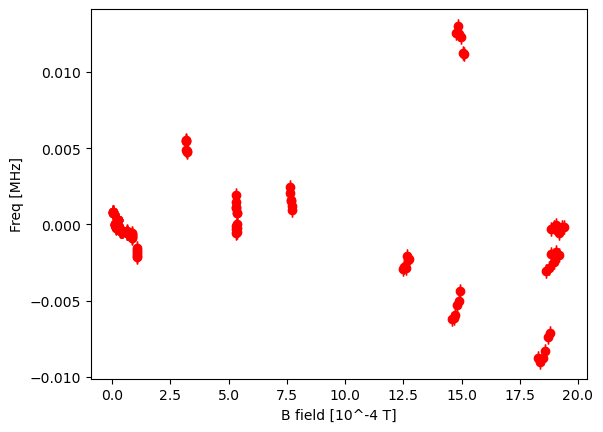

In [167]:


plt.errorbar(Rb85d1 * 10**4, Rb85d1Residual, xerr=uRb85d1, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, Rb85d2Residual, xerr=uRb85d2, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, Rb85d3Residual, xerr=uRb85d3, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, Rb85d4Residual, xerr=uRb85d4, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, Rb85d5Residual, xerr=uRb85d5, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, Rb85d6Residual, xerr=uRb85d6, capsize=5, label='residual of Rb85 dip1', fmt='o', color='red')


plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
plt.savefig("./figures/quadratic Zeeman residual mar 27", dpi=300)
plt.show()